In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.layers import Dense
from keras.callbacks import EarlyStopping
from keras.models import BatchNormalization
from keras.regularizers import L2

ModuleNotFoundError: No module named 'tensorflow'

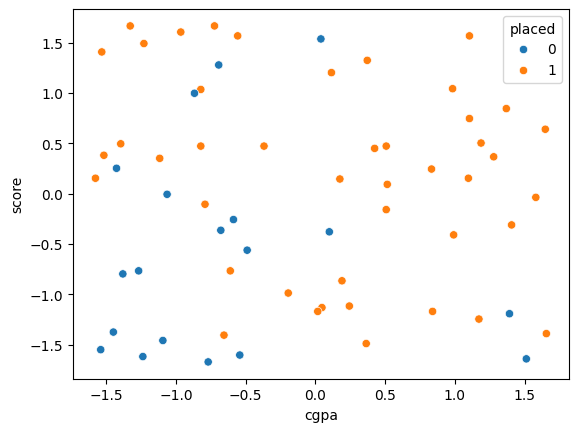

        cgpa     score
0   0.364309 -1.489426
1  -0.194656 -0.987757
2  -1.063318 -0.007221
3   1.187650  0.502049
4   1.104560  0.745283
..       ...       ...
58  0.175470  0.144800
59  0.371863  1.322963
60 -1.229496  1.490186
61 -0.866925  0.996118
62 -0.821603  0.471645

[63 rows x 2 columns] 0     1
1     1
2     0
3     1
4     1
     ..
58    1
59    1
60    1
61    0
62    1
Name: placed, Length: 63, dtype: int64
52.0 76.92307692307693


c:\Users\HP\Desktop\Projects\AI Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


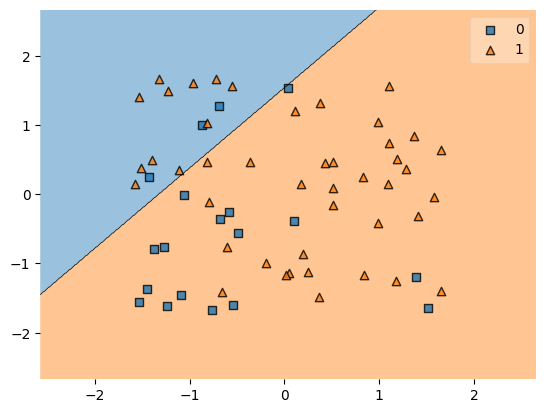

In [ ]:
dataset = pd.read_csv("../datasets/dl_cgpa_score_placement.csv")
dataset.head()
dataset.columns = dataset.columns.str.strip()
plt.Figure(figsize=(10,6))
sns.scatterplot(x="cgpa",y="score",hue="placed",data=dataset)
plt.show()
x =dataset.iloc[:,:-1]
y=dataset['placed']
print(x,y)
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=20)
pr = Perceptron()
pr.fit(x_train,y_train)
print(pr.score(x_train,y_train)*100,(pr.score(x_test,y_test)*100))
plt.Figure(figsize=(4,3))
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=pr)
plt.show()

In [ ]:
dataset = pd.read_csv("../datasets/bank_customer_dl_dataset.csv")
print(dataset.head())
print(dataset.isnull().sum())
plt.Figure(figsize=(10,6))
plt.show()
x =dataset.iloc[:,:-1]
y = dataset.iloc[:, -1]
print(x,y)
ss = StandardScaler()
x =  pd.DataFrame(ss.fit_transform(x),columns=x.columns)
print("x.shape",x.shape)
print(x)
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=20)
ann = Sequential()
ann.add(Dense(6,activation="relu",input_dim=8,kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(4,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(2,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(1,activation="sigmoid",kernel_regularizer=L2(l2=0.01)))
ann.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
ann.fit(x_train,y_train,batch_size=200,epochs=40, validation_data=(x_test,y_test),callbacks=EarlyStopping())
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]
plt.plot((i for i in range(1,14)),train_accuracy,label="train_accuracy")
plt.plot((i for i in range(1,14)),test_accuracy,label="test_accuracy")
plt.show()
prd = ann.predict(x_test)
prd_data= []
for i in prd:
    if i[0]>0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)
print(prd_data)
prd1 = ann.predict(x_train)
prd_data1 = []
for i in prd1:
    if i[0]>0.5:
        prd_data1.append(1)
    else:
        prd_data1.append(0)
print(prd_data1)
accuracy_score(y_test,prd_data)*100
accuracy_score(y_train,prd_data1)*100
prd_data = ann.predict(([]))
prd_data= []
for i in prd:
    if i[0]>0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          452   39       4   98111.28              2          0   
1          785   59       3  204149.86              3          0   
2          620   23       2  109783.73              3          1   
3          456   32       5   94236.11              3          0   
4          421   60       1  115669.95              3          0   

   IsActiveMember  EstimatedSalary  Exited  
0               0        146068.63       0  
1               1         61798.56       1  
2               1         88574.33       0  
3               0         33158.36       1  
4               0         44418.38       1  
CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
     CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0            452   39       4   98111.28         

NameError: name 'Sequential' is not defined